In [1]:
!pip install torch torchvision
!pip install opencv-python
!pip install pandas
!pip install matplotlib
!pip install seaborn
!pip install scikit-learn
!pip install tqdm

Defaulting to user installation because normal site-packages is not writeable
Defaulting to user installation because normal site-packages is not writeable
Defaulting to user installation because normal site-packages is not writeable
Defaulting to user installation because normal site-packages is not writeable
Defaulting to user installation because normal site-packages is not writeable
Defaulting to user installation because normal site-packages is not writeable
Defaulting to user installation because normal site-packages is not writeable


In [2]:
import os
import glob
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from tqdm import tqdm

import torch
import torch.nn as nn

from torchvision import transforms
from torchvision.models import efficientnet_b0

from torch.utils.data import Dataset
from torch.utils.data import DataLoader

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from sklearn.metrics import mean_absolute_error

In [4]:
DATASET_PATH = r"D:\ML-PROJECTS\long-hair detection\datasets\age\UTKFace"
images = glob.glob(
    os.path.join(DATASET_PATH, "*.jpg")
)

print("Total Images:", len(images))

Total Images: 23708


In [5]:
ages = []
genders = []

for img in images:

    file = os.path.basename(img)

    try:

        age = int(file.split("_")[0])

        gender = int(file.split("_")[1])

        ages.append(age)
        genders.append(gender)

    except:
        pass

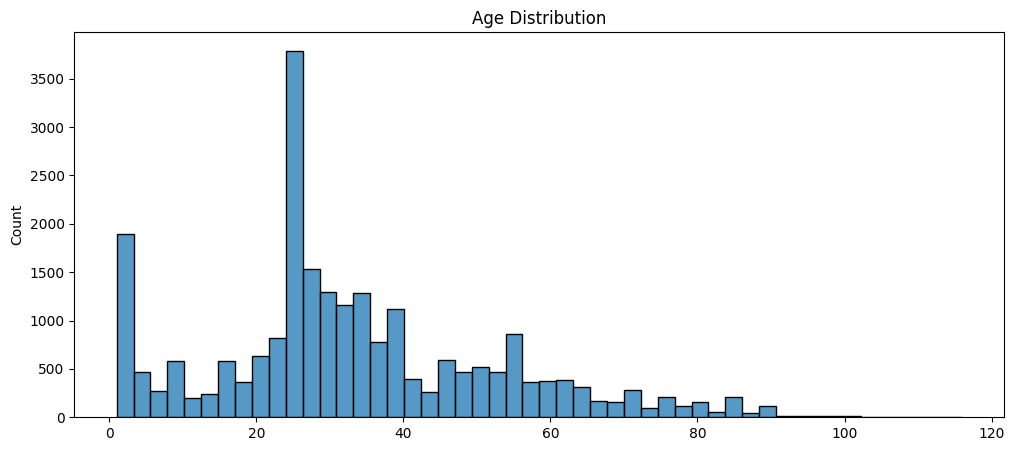

In [6]:
plt.figure(figsize=(12,5))

sns.histplot(ages,bins=50)

plt.title("Age Distribution")

plt.show()

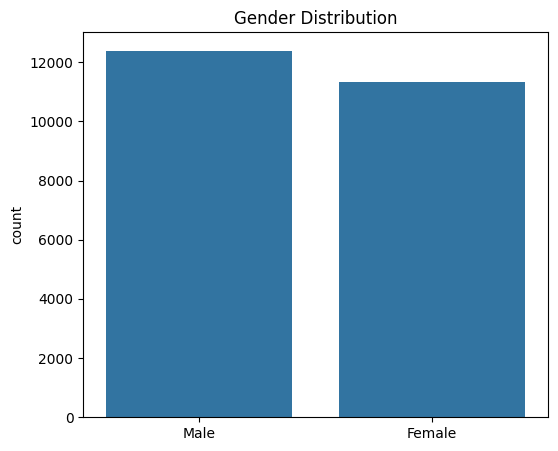

In [7]:
plt.figure(figsize=(6,5))

sns.countplot(x=genders)

plt.title("Gender Distribution")

plt.xticks([0,1],["Male","Female"])

plt.show()

In [8]:
train_paths, val_paths = train_test_split(
    images,
    test_size=0.2,
    random_state=42
)

print(len(train_paths))
print(len(val_paths))

18966
4742


In [9]:
transform = transforms.Compose([
    transforms.ToPILImage(),
    transforms.Resize((224,224)),
    transforms.ToTensor()
])

In [10]:
class UTKFaceDataset(Dataset):

    def __init__(self,image_paths):

        self.image_paths = image_paths

    def __len__(self):

        return len(self.image_paths)

    def __getitem__(self,idx):

        img_path = self.image_paths[idx]

        img = cv2.imread(img_path)

        img = cv2.cvtColor(
            img,
            cv2.COLOR_BGR2RGB
        )

        filename = os.path.basename(img_path)

        age = int(filename.split("_")[0])

        gender = int(filename.split("_")[1])

        img = transform(img)

        return img, age, gender

In [11]:
train_dataset = UTKFaceDataset(
    train_paths
)

val_dataset = UTKFaceDataset(
    val_paths
)

train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=32,
    shuffle=False
)

In [15]:
class AgeGenderNet(nn.Module):

    def __init__(self):

        super().__init__()

        self.backbone = efficientnet_b0(
            weights=None
        )

        features = self.backbone.classifier[1].in_features

        self.backbone.classifier = nn.Identity()

        self.age_head = nn.Sequential(

            nn.Linear(features,256),
            nn.ReLU(),

            nn.Dropout(0.3),

            nn.Linear(256,1)

        )

        self.gender_head = nn.Sequential(

            nn.Linear(features,256),
            nn.ReLU(),

            nn.Dropout(0.3),

            nn.Linear(256,2)

        )

    def forward(self,x):

        x = self.backbone(x)

        age = self.age_head(x)

        gender = self.gender_head(x)

        return age,gender

In [16]:
device = torch.device(
    "cuda" if torch.cuda.is_available()
    else "cpu"
)

print(device)

cpu


In [17]:
model = AgeGenderNet().to(device)

age_loss_fn = nn.MSELoss()

gender_loss_fn = nn.CrossEntropyLoss()

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=0.0001
)

In [18]:
epochs = 15

for epoch in range(epochs):

    model.train()

    running_loss = 0

    for imgs, ages, genders in tqdm(train_loader):

        imgs = imgs.to(device)

        ages = ages.float().to(device)

        genders = genders.long().to(device)

        optimizer.zero_grad()

        pred_age, pred_gender = model(imgs)

        age_loss = age_loss_fn(
            pred_age.squeeze(),
            ages
        )

        gender_loss = gender_loss_fn(
            pred_gender,
            genders
        )

        loss = age_loss + gender_loss

        loss.backward()

        optimizer.step()

        running_loss += loss.item()

    print(
        f"Epoch {epoch+1}/{epochs} Loss:{running_loss:.4f}"
    )

100%|██████████| 593/593 [14:02<00:00,  1.42s/it]


Epoch 1/15 Loss:276972.7320


100%|██████████| 593/593 [12:00<00:00,  1.22s/it]


Epoch 2/15 Loss:119868.3787


100%|██████████| 593/593 [12:01<00:00,  1.22s/it]


...

Epoch 13/15 Loss:31339.4618


100%|██████████| 593/593 [11:51<00:00,  1.20s/it]


Epoch 14/15 Loss:29096.6777


100%|██████████| 593/593 [11:52<00:00,  1.20s/it]

Epoch 15/15 Loss:27967.4799


In [19]:
torch.save(
    model.state_dict(),
    "age_gender_model.pth"
)

print("Saved")

Saved


In [20]:
model.eval()

true_gender = []
pred_gender = []

with torch.no_grad():

    for imgs, ages, genders in tqdm(val_loader):

        imgs = imgs.to(device)

        _, outputs = model(imgs)

        preds = torch.argmax(
            outputs,
            dim=1
        )

        pred_gender.extend(
            preds.cpu().numpy()
        )

        true_gender.extend(
            genders.numpy()
        )

100%|██████████| 149/149 [01:25<00:00,  1.74it/s]


In [21]:
print(
    classification_report(
        true_gender,
        pred_gender
    )
)

              precision    recall  f1-score   support

           0       0.65      0.81      0.72      2485
           1       0.72      0.52      0.61      2257

    accuracy                           0.68      4742
   macro avg       0.69      0.67      0.67      4742
weighted avg       0.68      0.68      0.67      4742



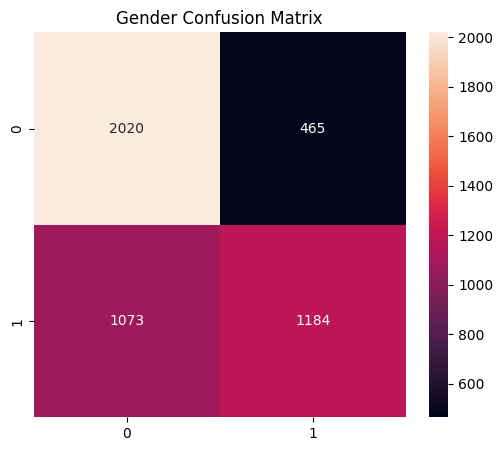

In [22]:
cm = confusion_matrix(
    true_gender,
    pred_gender
)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d"
)

plt.title("Gender Confusion Matrix")

plt.show()

In [23]:
true_age = []
pred_age = []

with torch.no_grad():

    for imgs, ages, genders in val_loader:

        imgs = imgs.to(device)

        outputs,_ = model(imgs)

        pred_age.extend(
            outputs.squeeze()
            .cpu()
            .numpy()
        )

        true_age.extend(
            ages.numpy()
        )

In [24]:
mae = mean_absolute_error(
    true_age,
    pred_age
)

print("MAE:",mae)

MAE: 7.039335332920862


In [27]:
img_path = images[100]

img = cv2.imread(img_path)

rgb = cv2.cvtColor(
    img,
    cv2.COLOR_BGR2RGB
)

input_img = transform(rgb)

input_img = input_img.unsqueeze(0)

input_img = input_img.to(device)

model.eval()

with torch.no_grad():

    age_pred, gender_pred = model(input_img)

age = int(age_pred.item())

gender = torch.argmax(
    gender_pred,
    dim=1
).item()

gender_text = (
    "Male"
    if gender==0
    else "Female"
)

print("Age:",age)
print("Gender:",gender_text)

Age: 12
Gender: Female
